<a href="https://colab.research.google.com/github/MiniMaliZ/Sistem-Rekomendasi-Kost/blob/main/03_Teorema_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sistem Rekomendasi Kos — Teorema Bayes

Mata Kuliah: Sistem Berbasis Pengetahuan  
Politeknik Negeri Malang — Jurusan Teknologi Informasi

---

## Konsep Teorema Bayes dalam Rekomendasi Kos

**Teorema Bayes** menghitung probabilitas posterior suatu hipotesis berdasarkan bukti:

$$P(H|E) = \frac{P(E|H) \cdot P(H)}{P(E)}$$

Dalam konteks sistem rekomendasi kos:
- H = Hipotesis: "Kos ini direkomendasikan" (kelas: Premium, Value, Budget, dll.)
- E = Evidence: fitur-fitur kos (harga, rating, fasilitas, tipe)
- P(H|E) = Probabilitas kos direkomendasikan ke kelas H, given fitur E



In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from collections import defaultdict
warnings.filterwarnings('ignore')
print('Library siap!')

Library siap!


## 📂 Load & Preprocessing Data

In [4]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [5]:
df_raw = pd.read_excel('Mamikos_Jabodetabek_Data.xlsx')

def parse_price(p):
    cleaned = re.sub(r'[Rp.\s]', '', str(p))
    try: return int(cleaned)
    except: return np.nan

def parse_rating(r):
    if str(r).strip() == 'Not found': return np.nan
    try: return float(r)
    except: return np.nan

def parse_room_size(s):
    m = re.search(r'([\d.]+)\s*[xX]\s*([\d.]+)', str(s))
    return float(m.group(1)) * float(m.group(2)) if m else np.nan

df = df_raw.copy()
df['price_numeric'] = df['price'].apply(parse_price)
df['rating_numeric'] = df['rating'].apply(parse_rating)
df['rating_numeric'] = df['rating_numeric'].fillna(df['rating_numeric'].median())
df['room_size_m2'] = df['room_size'].apply(parse_room_size)
df['room_size_m2'] = df['room_size_m2'].fillna(df['room_size_m2'].median())
df['electricity_included'] = df['is_electricity_included'].apply(lambda x: 1 if 'termasuk' in str(x).lower() else 0)

for col, kw in [('has_ac','AC'),('has_wifi','WiFi'),('has_private_bathroom','K. Mandi Dalam'),
                ('has_parking','Parkir'),('has_cctv','CCTV'),('has_laundry','Laundry'),
                ('has_kitchen','Dapur'),('has_wardrobe','Lemari Baju'),('has_bed','Kasur')]:
    df[col] = df['all_facilities_bs'].apply(lambda x: 1 if kw.lower() in str(x).lower() else 0)

df['total_facilities'] = df[['has_ac','has_wifi','has_private_bathroom','has_parking',
                               'has_cctv','has_laundry','has_kitchen','has_wardrobe','has_bed']].sum(axis=1)

def kat_harga(h):
    if h < 1_000_000: return 'murah'
    elif h < 2_000_000: return 'sedang'
    elif h < 3_500_000: return 'mahal'
    return 'sangat_mahal'

def kat_rating(r):
    if r >= 4.5: return 'sangat_baik'
    elif r >= 4.0: return 'baik'
    elif r >= 3.0: return 'cukup'
    return 'kurang'

def kat_ukuran(m2):
    if m2 >= 16: return 'luas'
    elif m2 >= 9: return 'sedang'
    return 'sempit'

def kat_fasilitas(t):
    if t >= 7: return 'lengkap'
    elif t >= 4: return 'standar'
    return 'minim'

df['kategori_harga'] = df['price_numeric'].apply(kat_harga)
df['kategori_rating'] = df['rating_numeric'].apply(kat_rating)
df['kategori_ukuran'] = df['room_size_m2'].apply(kat_ukuran)
df['kategori_fasilitas'] = df['total_facilities'].apply(kat_fasilitas)
df = df.dropna(subset=['price_numeric'])
df = df[df['price_numeric'] > 0].reset_index(drop=True)
print(f'Data preprocessed: {df.shape}')

Data preprocessed: (2485, 35)


## 🏷️ Buat Label Kelas Rekomendasi (Target Variable)

Untuk Naive Bayes, kita perlu label kelas. Kelas ditentukan berdasarkan kombinasi harga-rating sebagai ground truth.

In [6]:
def buat_kelas_rekomendasi(row):
    """
    Membuat label kelas berdasarkan heuristik kombinasi fitur.
    Ini menjadi 'ground truth' untuk training Naive Bayes.
    """
    harga = row['kategori_harga']
    rating = row['kategori_rating']
    fasilitas = row['kategori_fasilitas']

    # Kelas Premium
    if harga in ['mahal', 'sangat_mahal'] and rating == 'sangat_baik' and fasilitas == 'lengkap':
        return 'Premium'
    # Kelas Direkomendasikan
    elif rating in ['baik', 'sangat_baik'] and fasilitas in ['standar', 'lengkap']:
        return 'Direkomendasikan'
    # Kelas Budget
    elif harga == 'murah' and rating in ['cukup', 'baik', 'sangat_baik']:
        return 'Budget'
    # Kelas Kurang Sesuai
    elif rating == 'kurang' or fasilitas == 'minim':
        return 'Kurang Sesuai'
    else:
        return 'Standar'

df['kelas_rekomendasi'] = df.apply(buat_kelas_rekomendasi, axis=1)

print('=== Distribusi Kelas Rekomendasi ===')
print(df['kelas_rekomendasi'].value_counts())
print(f'Total proporsi: {df["kelas_rekomendasi"].value_counts(normalize=True).round(3) * 100}')

=== Distribusi Kelas Rekomendasi ===
kelas_rekomendasi
Direkomendasikan    1794
Premium              507
Budget                79
Kurang Sesuai         72
Standar               33
Name: count, dtype: int64
Total proporsi: kelas_rekomendasi
Direkomendasikan    72.2
Premium             20.4
Budget               3.2
Kurang Sesuai        2.9
Standar              1.3
Name: proportion, dtype: float64


**Implementasi Naive Bayes dari Scratch**


### Step 1: Training — Hitung Prior & Likelihood

In [7]:
class NaiveBayesKos:
    """
    Naive Bayes Classifier dari scratch untuk rekomendasi kos.
    Menggunakan Laplace Smoothing untuk menghindari zero probability.
    """

    def __init__(self, alpha=1.0):
        self.alpha = alpha  # Laplace smoothing parameter
        self.classes_ = None
        self.prior_ = {}
        self.likelihood_ = {}  # P(feature=value | class)
        self.feature_values_ = {}  # Unique values per feature

    def fit(self, X, y, features):
        """
        Training Naive Bayes.
        X: DataFrame fitur kategorik
        y: Series label
        features: list nama kolom fitur
        """
        self.features_ = features
        self.classes_ = y.unique()
        n_total = len(y)

        # === Hitung Prior P(H) ===
        for c in self.classes_:
            count_c = (y == c).sum()
            self.prior_[c] = count_c / n_total

        # === Hitung Likelihood P(E|H) ===
        for feat in features:
            self.feature_values_[feat] = X[feat].unique()
            self.likelihood_[feat] = {}

            for c in self.classes_:
                self.likelihood_[feat][c] = {}
                subset = X[y == c][feat]
                n_class = len(subset)
                n_values = len(self.feature_values_[feat])

                for val in self.feature_values_[feat]:
                    count_val = (subset == val).sum()
                    # Laplace Smoothing: P(E|H) = (count + alpha) / (n_class + alpha * n_values)
                    self.likelihood_[feat][c][val] = (
                        (count_val + self.alpha) / (n_class + self.alpha * n_values)
                    )

        print(f'Model dilatih dengan {n_total} data, {len(self.classes_)} kelas')
        return self

    def predict_proba_single(self, x_dict):
        """
        Hitung P(H|E) untuk satu sampel.
        Menggunakan log-space untuk mencegah underflow.
        """
        log_posteriors = {}

        for c in self.classes_:
            # log P(H) — prior
            log_posterior = np.log(self.prior_[c])

            # log P(E1|H) * P(E2|H) * ... = sum of log likelihoods
            for feat in self.features_:
                val = x_dict.get(feat)
                if val in self.likelihood_[feat][c]:
                    log_posterior += np.log(self.likelihood_[feat][c][val])
                else:
                    # Nilai baru: gunakan smoothing
                    log_posterior += np.log(self.alpha / (len(self.feature_values_[feat]) + self.alpha))

            log_posteriors[c] = log_posterior

        # Konversi dari log ke probabilitas
        max_log = max(log_posteriors.values())
        posteriors = {c: np.exp(lp - max_log) for c, lp in log_posteriors.items()}
        total = sum(posteriors.values())
        posteriors = {c: v/total for c, v in posteriors.items()}

        return posteriors

    def predict(self, X):
        """
        Prediksi kelas untuk seluruh dataset.
        """
        predictions = []
        for _, row in X.iterrows():
            x_dict = row.to_dict()
            posteriors = self.predict_proba_single(x_dict)
            best_class = max(posteriors, key=posteriors.get)
            predictions.append(best_class)
        return predictions

    def predict_proba_df(self, X):
        """
        Kembalikan probabilitas untuk setiap kelas.
        """
        results = []
        for _, row in X.iterrows():
            x_dict = row.to_dict()
            posteriors = self.predict_proba_single(x_dict)
            results.append(posteriors)
        return pd.DataFrame(results)

print('Class NaiveBayesKos siap!')

Class NaiveBayesKos siap!


### Step 2: Train-Test Split & Training

In [8]:
from sklearn.model_selection import train_test_split

# Fitur kategorik untuk Naive Bayes
FITUR = [
    'kategori_harga', 'kategori_rating', 'kategori_ukuran',
    'kategori_fasilitas', 'tipe_kos',
    'has_ac', 'has_wifi', 'has_private_bathroom',
    'has_cctv', 'has_parking', 'electricity_included'
]

X = df[FITUR].copy()
# Konversi binary ke string agar Naive Bayes kategorik
for col in ['has_ac', 'has_wifi', 'has_private_bathroom', 'has_cctv', 'has_parking', 'electricity_included']:
    X[col] = X[col].astype(str)

y = df['kelas_rekomendasi']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

# Training Naive Bayes
nb_model = NaiveBayesKos(alpha=1.0)
nb_model.fit(X_train, y_train, FITUR)

Train: (1988, 11), Test: (497, 11)
Model dilatih dengan 1988 data, 5 kelas


### Step 3: Prior Probabilities — P(H)

In [9]:
print('=== PRIOR PROBABILITY P(H) ===')
print('Probabilitas awal setiap kelas rekomendasi:')
for c, p in sorted(nb_model.prior_.items(), key=lambda x: -x[1]):
    print(f'  P({c}) = {p:.4f} ({p*100:.2f}%)')

=== PRIOR PROBABILITY P(H) ===
Probabilitas awal setiap kelas rekomendasi:
  P(Direkomendasikan) = 0.7218 (72.18%)
  P(Premium) = 0.2042 (20.42%)
  P(Budget) = 0.0317 (3.17%)
  P(Kurang Sesuai) = 0.0292 (2.92%)
  P(Standar) = 0.0131 (1.31%)


### Step 4: Likelihood Beberapa Fitur Penting — P(E|H)

In [11]:
print('=== LIKELIHOOD P(E|H) — Contoh Fitur Penting ===\n')

fitur_tampil = ['kategori_harga', 'kategori_rating', 'has_ac']
for feat in fitur_tampil:
    print(f'--- Fitur: {feat} ---')
    for val in nb_model.feature_values_[feat]:
        print(f'  P({feat}={val} | kelas):')
        for c in nb_model.classes_:
            prob = nb_model.likelihood_[feat][c].get(val, 0)
            print(f'    P({val}|{c}) = {prob:.4f}')
    print()

=== LIKELIHOOD P(E|H) — Contoh Fitur Penting ===

--- Fitur: kategori_harga ---
  P(kategori_harga=sedang | kelas):
    P(sedang|Direkomendasikan) = 0.7192
    P(sedang|Premium) = 0.0024
    P(sedang|Kurang Sesuai) = 0.7419
    P(sedang|Budget) = 0.0149
    P(sedang|Standar) = 0.7000
  P(kategori_harga=mahal | kelas):
    P(mahal|Direkomendasikan) = 0.0556
    P(mahal|Premium) = 0.8439
    P(mahal|Kurang Sesuai) = 0.1774
    P(mahal|Budget) = 0.0149
    P(mahal|Standar) = 0.2000
  P(kategori_harga=murah | kelas):
    P(murah|Direkomendasikan) = 0.2175
    P(murah|Premium) = 0.0024
    P(murah|Kurang Sesuai) = 0.0484
    P(murah|Budget) = 0.9552
    P(murah|Standar) = 0.0333
  P(kategori_harga=sangat_mahal | kelas):
    P(sangat_mahal|Direkomendasikan) = 0.0076
    P(sangat_mahal|Premium) = 0.1512
    P(sangat_mahal|Kurang Sesuai) = 0.0323
    P(sangat_mahal|Budget) = 0.0149
    P(sangat_mahal|Standar) = 0.0667

--- Fitur: kategori_rating ---
  P(kategori_rating=sangat_baik | kelas):
  

### Step 5: Prediksi & Evaluasi

In [12]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = nb_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f'Akurasi Naive Bayes: {acc:.4f} ({acc*100:.2f}%)')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

Akurasi Naive Bayes: 0.9819 (98.19%)

=== Classification Report ===
                  precision    recall  f1-score   support

          Budget       0.94      0.94      0.94        16
Direkomendasikan       0.99      0.99      0.99       359
   Kurang Sesuai       1.00      0.71      0.83        14
         Premium       0.99      0.98      0.99       101
         Standar       0.78      1.00      0.88         7

        accuracy                           0.98       497
       macro avg       0.94      0.93      0.92       497
    weighted avg       0.98      0.98      0.98       497



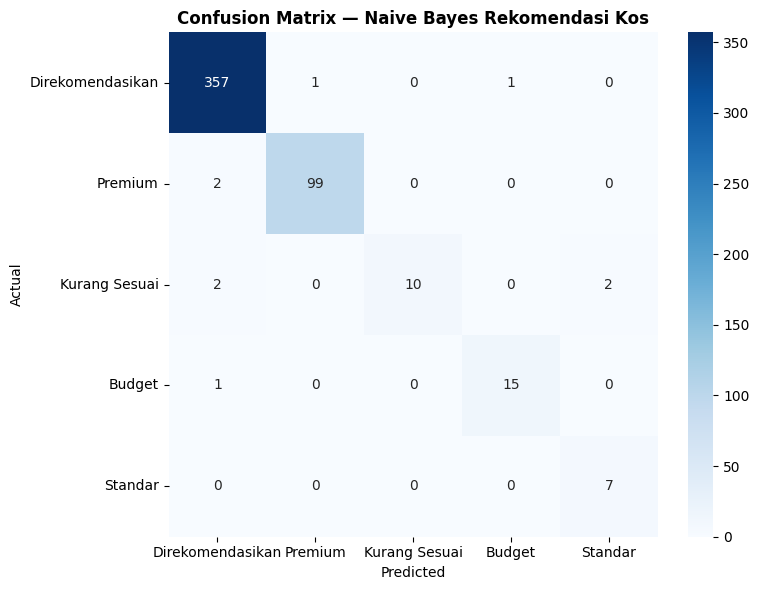

In [13]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=nb_model.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=nb_model.classes_, yticklabels=nb_model.classes_)
plt.title('Confusion Matrix — Naive Bayes Rekomendasi Kos', fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('bayes_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Rekomendasi Interaktif dengan Posterior Probability

In [14]:
def rekomendasi_bayes(df, nb_model, fitur, preferensi_user, top_n=10):
    """
    Menggunakan Naive Bayes untuk memberikan rekomendasi kos.
    Output disertai probabilitas posterior P(H|E).
    """
    df_filtered = df.copy()

    # Filter awal berdasarkan preferensi
    if 'budget_max' in preferensi_user:
        df_filtered = df_filtered[df_filtered['price_numeric'] <= preferensi_user['budget_max']]
    if 'tipe_kos' in preferensi_user:
        df_filtered = df_filtered[df_filtered['tipe_kos'] == preferensi_user['tipe_kos']]
    if 'region' in preferensi_user:
        df_filtered = df_filtered[df_filtered['region'].str.contains(preferensi_user['region'], case=False, na=False)]

    if df_filtered.empty:
        print('Tidak ada kos yang sesuai filter.')
        return pd.DataFrame()

    X_feat = df_filtered[fitur].copy()
    for col in ['has_ac', 'has_wifi', 'has_private_bathroom', 'has_cctv', 'has_parking', 'electricity_included']:
        if col in X_feat.columns:
            X_feat[col] = X_feat[col].astype(str)

    # Hitung posterior probability
    proba_df = nb_model.predict_proba_df(X_feat)

    # Skor = P(Premium) * 5 + P(Direkomendasikan) * 4 + P(Budget) * 3 + P(Standar) * 2
    kelas_bobot = {'Premium': 5, 'Direkomendasikan': 4, 'Budget': 3, 'Standar': 2, 'Kurang Sesuai': 1}
    bayes_score = sum(proba_df[c] * w for c, w in kelas_bobot.items() if c in proba_df.columns)

    # Prediksi kelas
    kelas_pred = proba_df.idxmax(axis=1)
    proba_max = proba_df.max(axis=1)

    df_result = df_filtered.copy()
    df_result['bayes_score'] = bayes_score.values
    df_result['bayes_kelas'] = kelas_pred.values
    df_result['bayes_confidence'] = proba_max.values

    # Tambahkan probabilitas per kelas
    for c in proba_df.columns:
        df_result[f'prob_{c}'] = proba_df[c].values

    df_result = df_result.sort_values('bayes_score', ascending=False)

    kolom_tampil = ['room_name', 'region', 'tipe_kos', 'price_numeric', 'rating_numeric',
                    'bayes_kelas', 'bayes_confidence', 'bayes_score']
    return df_result[kolom_tampil].head(top_n)


# ============================================
# CONTOH 1: Profesional budget sedang-mahal
# ============================================
print('=== REKOMENDASI BAYES 1: Profesional di Jakarta Selatan ===')
pref1 = {'budget_max': 4_000_000, 'region': 'Jakarta Selatan'}
r1 = rekomendasi_bayes(df, nb_model, FITUR, pref1, top_n=5)
print(r1.to_string())

=== REKOMENDASI BAYES 1: Profesional di Jakarta Selatan ===
                                                                          room_name           region    tipe_kos  price_numeric  rating_numeric bayes_kelas  bayes_confidence  bayes_score
10                      Kost 3tranches Home Senopati Kebayoran Baru Jakarta Selatan  Jakarta Selatan  Kos Campur        3800000             4.6     Premium          0.991789     4.991414
1694            Kost Singgahsini Cleo Damai 2 Tipe A Kebayoran Baru Jakarta Selatan  Jakarta Selatan  Kos Campur        3625000             4.6     Premium          0.991789     4.991414
2357  Kost The Legacy Residence Pondok Indah Syariah Kebayoran Lama Jakarta Selatan  Jakarta Selatan  Kos Campur        3850000             4.6     Premium          0.991789     4.991414
1739          Kost Singgahsini Dito Jati Padang Tipe A Pasar Minggu Jakarta Selatan  Jakarta Selatan  Kos Campur        3025000             4.8     Premium          0.989464     4.989257
2030 

In [15]:
# ============================================
# CONTOH 2: Mahasiswi Depok
# ============================================
print('=== REKOMENDASI BAYES 2: Mahasiswi di Depok ===')
pref2 = {'budget_max': 1_800_000, 'tipe_kos': 'Kos Putri', 'region': 'Depok'}
r2 = rekomendasi_bayes(df, nb_model, FITUR, pref2, top_n=5)
print(r2.to_string())

=== REKOMENDASI BAYES 2: Mahasiswi di Depok ===
                                       room_name region   tipe_kos  price_numeric  rating_numeric       bayes_kelas  bayes_confidence  bayes_score
6                Kost 28 Pondoklabu Cinere Depok  Depok  Kos Putri        1350000             4.8  Direkomendasikan           0.98885     4.008942
17              Kost A21 Pondoklabu Cinere Depok  Depok  Kos Putri        1600000             4.8  Direkomendasikan           0.98885     4.008942
364                Kost Bambon Tipe 1 Beji Depok  Depok  Kos Putri        1350000             4.6  Direkomendasikan           0.98885     4.008942
1841  Kost Singgahsini Hana UI Tipe D Beji Depok  Depok  Kos Putri        1425000             4.9  Direkomendasikan           0.98885     4.008942
1842  Kost Singgahsini Hana UI Tipe E Beji Depok  Depok  Kos Putri        1525000             4.6  Direkomendasikan           0.98885     4.008942


In [16]:
# =============================================
# DEMO: Hitung manual posterior untuk 1 kos
# =============================================
print('=== DEMO MANUAL: Posterior Probability untuk Kos Sample ===')
sample = df.iloc[10]
print(f'Kos: {sample["room_name"]}')
print(f'Harga: {sample["price_numeric"]:,} → Kategori: {sample["kategori_harga"]}')
print(f'Rating: {sample["rating_numeric"]} → Kategori: {sample["kategori_rating"]}')
print(f'Fasilitas: {sample["total_facilities"]} fasilitas → {sample["kategori_fasilitas"]}')
print()

x_sample = {}
for feat in FITUR:
    val = sample[feat]
    x_sample[feat] = str(val) if feat in ['has_ac','has_wifi','has_private_bathroom','has_cctv','has_parking','electricity_included'] else val

posteriors = nb_model.predict_proba_single(x_sample)
print('Probabilitas Posterior P(H|E):')
for kelas, prob in sorted(posteriors.items(), key=lambda x: -x[1]):
    bar = '█' * int(prob * 30)
    print(f'  P({kelas:20s}|E) = {prob:.4f}  {bar}')
print(f'\nKelas Prediksi: {max(posteriors, key=posteriors.get)}')

=== DEMO MANUAL: Posterior Probability untuk Kos Sample ===
Kos: Kost 3tranches Home Senopati Kebayoran Baru Jakarta Selatan
Harga: 3,800,000 → Kategori: sangat_mahal
Rating: 4.6 → Kategori: sangat_baik
Fasilitas: 8 fasilitas → lengkap

Probabilitas Posterior P(H|E):
  P(Premium             |E) = 0.9918  █████████████████████████████
  P(Direkomendasikan    |E) = 0.0080  
  P(Standar             |E) = 0.0002  
  P(Kurang Sesuai       |E) = 0.0000  
  P(Budget              |E) = 0.0000  

Kelas Prediksi: Premium


### Visualisasi & Ringkasan

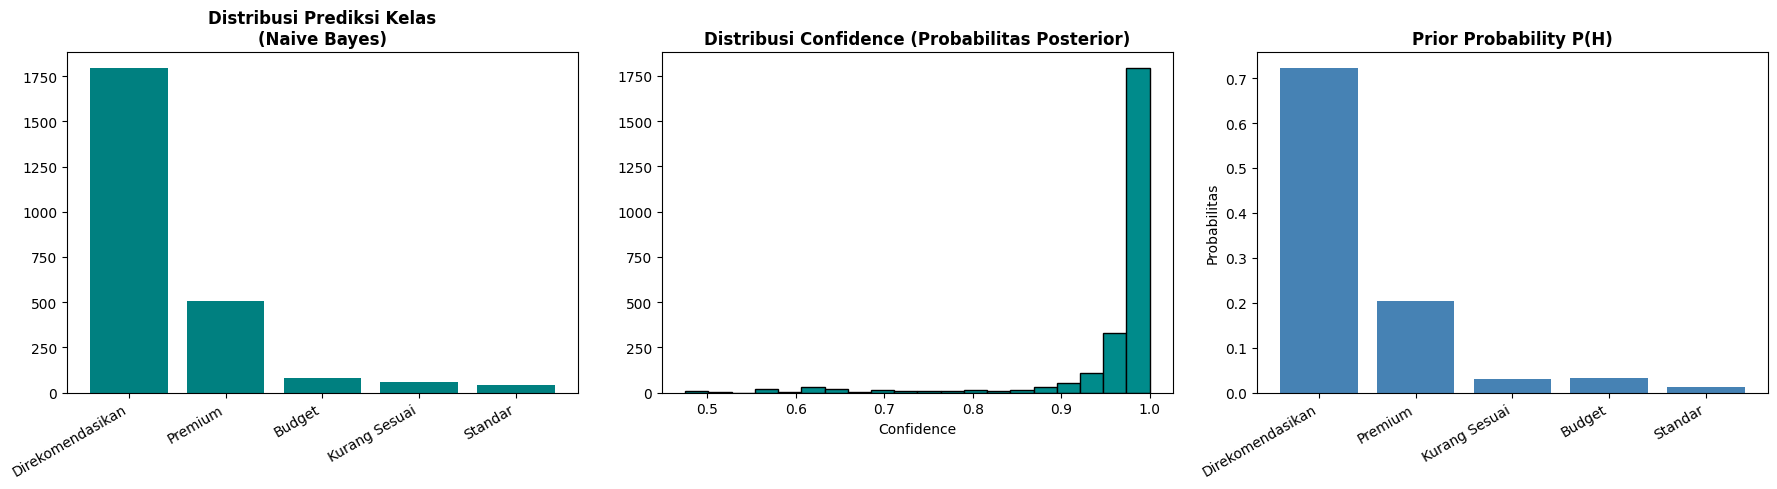

In [17]:
import matplotlib.pyplot as plt

# Hitung prediksi untuk seluruh data
X_all = df[FITUR].copy()
for col in ['has_ac','has_wifi','has_private_bathroom','has_cctv','has_parking','electricity_included']:
    X_all[col] = X_all[col].astype(str)

y_pred_all = nb_model.predict(X_all)
proba_all = nb_model.predict_proba_df(X_all)

df['bayes_pred'] = y_pred_all
df['bayes_confidence'] = proba_all.max(axis=1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Prior vs Posterior distribution
pred_counts = pd.Series(y_pred_all).value_counts()
axes[0].bar(pred_counts.index, pred_counts.values, color='teal')
axes[0].set_title('Distribusi Prediksi Kelas\n(Naive Bayes)', fontweight='bold')
axes[0].set_xticklabels(pred_counts.index, rotation=30, ha='right')

# Plot 2: Confidence Histogram
axes[1].hist(df['bayes_confidence'], bins=20, color='darkcyan', edgecolor='black')
axes[1].set_title('Distribusi Confidence (Probabilitas Posterior)', fontweight='bold')
axes[1].set_xlabel('Confidence')

# Plot 3: Prior probabilities
priors = pd.Series(nb_model.prior_)
axes[2].bar(priors.index, priors.values, color='steelblue')
axes[2].set_title('Prior Probability P(H)', fontweight='bold')
axes[2].set_ylabel('Probabilitas')
axes[2].set_xticklabels(priors.index, rotation=30, ha='right')

plt.tight_layout()
plt.savefig('bayes_visualisasi.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
print('=' * 60)
print('RINGKASAN TEOREMA BAYES (NAIVE BAYES)')
print('=' * 60)
print(f'Total data          : {len(df)}')
print(f'Fitur digunakan     : {len(FITUR)}')
print(f'Jumlah kelas        : {len(nb_model.classes_)}')
print(f'Akurasi (test set)  : {acc:.4f} ({acc*100:.2f}%)')
print(f'Rata-rata confidence: {df["bayes_confidence"].mean():.4f}')
print()
print('Formula yang digunakan:')
print('  P(H|E) ∝ P(H) × ΠP(Ei|H)  (Naïve Bayes — asumsi independensi)')
print('  Dengan Laplace Smoothing: P(Ei|H) = (count + α) / (N_class + α × N_values)')
print()
print('Kelebihan Naive Bayes:')
print('  - Memperhitungkan ketidakpastian dengan probabilitas')
print('  - Confidence score membantu pengguna memahami kekuatan rekomendasi')
print('  - Training sangat cepat')
print()
print('Keterbatasan Naive Bayes:')
print('  - Asumsi independensi antar fitur jarang terpenuhi di dunia nyata')
print('  - Label kelas perlu dibuat manual sebagai ground truth')

RINGKASAN TEOREMA BAYES (NAIVE BAYES)
Total data          : 2485
Fitur digunakan     : 11
Jumlah kelas        : 5
Akurasi (test set)  : 0.9819 (98.19%)
Rata-rata confidence: 0.9627

Formula yang digunakan:
  P(H|E) ∝ P(H) × ΠP(Ei|H)  (Naïve Bayes — asumsi independensi)
  Dengan Laplace Smoothing: P(Ei|H) = (count + α) / (N_class + α × N_values)

Kelebihan Naive Bayes:
  - Memperhitungkan ketidakpastian dengan probabilitas
  - Confidence score membantu pengguna memahami kekuatan rekomendasi
  - Training sangat cepat

Keterbatasan Naive Bayes:
  - Asumsi independensi antar fitur jarang terpenuhi di dunia nyata
  - Label kelas perlu dibuat manual sebagai ground truth
